# **Import & Settings**

In [1]:
# import library dan pengaturan tampilan
import os
from pathlib import Path

import pandas as pd
import numpy as np

# preprocessing & model
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# util
import joblib

# viz
import matplotlib.pyplot as plt
import seaborn as sns

# pandas display (agar kolom tidak terpotong)
pd.set_option('display.max_colwidth', 200)

# random seed untuk reproducibility
random_state = 42

# **Load Dataset Pumpkin Seeds**

In [50]:
# sinkronisasi dengan drive
from google.colab import drive
drive.mount('/content/gdrive')

# load dataset
import pandas as pd

df = pd.read_csv('/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum06/datasets/pumpkin-seeds.csv', sep=',')
df.head()

# link pumpkin-seeds dataset
# https://www.kaggle.com/datasets/muratkokludataset/pumpkin-seeds-dataset/data

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,"888,242","326,1485","220,2388",56831,"267,6805","0,7376","0,9902","0,7453","0,8963","1,4809","0,8207",Çerçevelik
1,76631,"1068,146","417,1932","234,2289",77280,"312,3614","0,8275","0,9916","0,7151","0,844","1,7811","0,7487",Çerçevelik
2,71623,"1082,987","435,8328","211,0457",72663,"301,9822","0,8749","0,9857","0,74","0,7674","2,0651","0,6929",Çerçevelik
3,66458,"992,051","381,5638","222,5322",67118,"290,8899","0,8123","0,9902","0,7396","0,8486","1,7146","0,7624",Çerçevelik
4,66107,"998,146","383,8883","220,4545",67117,"290,1207","0,8187","0,985","0,6752","0,8338","1,7413","0,7557",Çerçevelik


In [5]:
# melihat info detail dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Area               2500 non-null   int64 
 1   Perimeter          2500 non-null   object
 2   Major_Axis_Length  2500 non-null   object
 3   Minor_Axis_Length  2500 non-null   object
 4   Convex_Area        2500 non-null   int64 
 5   Equiv_Diameter     2500 non-null   object
 6   Eccentricity       2500 non-null   object
 7   Solidity           2500 non-null   object
 8   Extent             2500 non-null   object
 9   Roundness          2500 non-null   object
 10  Aspect_Ration      2500 non-null   object
 11  Compactness        2500 non-null   object
 12  Class              2500 non-null   object
dtypes: int64(2), object(11)
memory usage: 254.0+ KB


In [6]:
# menampilkan statistika deskriptif
df.describe()

,Area,Convex_Area
count,2500.000000,2500.000000
mean,80658.220800,81508.084400
std,13664.510228,13764.092788
min,47939.000000,48366.000000
25%,70765.000000,71512.000000
50%,79076.000000,79872.000000
75%,89757.500000,90797.750000
max,136574.000000,138384.000000


In [11]:
# cek missing values dan tentukan kolom label
print("jumlah missing per kolom:")
display(df.isnull().sum())

# coba deteksi kolom target (label). jika sudah tahu nama kolom label, set label_col.
# common names: 'class','type','species','grain','label' - periksa unique untuk kandidat
print("\nkolom dataset:", df.columns.tolist())

# jika kamu sudah tahu nama kolom label, ganti value berikut:
label_col = None  # tambahkan nama kolom label jika sudah tahu, mis: 'g' atau 'class'

# otomatis pilih kandidat label: kolom object dengan jumlah unique kecil
if label_col is None:
    candidates = [c for c in df.columns if df[c].dtype == 'object' or df[c].nunique() < 30]
    print("calon kolom label (cek manual):", candidates)
    # kamu bisa set label_col = 'nama_kolom' berdasarkan output di atas

# tampilkan unique counts untuk candidate columns supaya kamu pilih
for c in candidates:
    print(f"\n{c} -> unique count: {df[c].nunique()}")
    display(df[c].value_counts().head(10))


jumlah missing per kolom:


,0
Area,0
Perimeter,0
Major_Axis_Length,0
Minor_Axis_Length,0
Convex_Area,0
Equiv_Diameter,0
Eccentricity,0
Solidity,0
Extent,0
Roundness,0



kolom dataset: ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Convex_Area', 'Equiv_Diameter', 'Eccentricity', 'Solidity', 'Extent', 'Roundness', 'Aspect_Ration', 'Compactness', 'Class']
calon kolom label (cek manual): ['Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Equiv_Diameter', 'Eccentricity', 'Solidity', 'Extent', 'Roundness', 'Aspect_Ration', 'Compactness', 'Class']

Perimeter -> unique count: 2490


,count
Perimeter,
"1187,56",2
"1192,175",2
"1103,068",2
"1023,719",2
"1014,49",2
"1134,729",2
"1206,002",2
"1253,276",2
"1217,112",2



Major_Axis_Length -> unique count: 2499


...

,count
Aspect_Ration,
"1,8606",4
"1,8491",4
"2,2067",3
"2,2797",3
"2,3783",3
"1,9006",3
"1,8454",3
"2,4033",3
"2,031",3



Compactness -> unique count: 1405


,count
Compactness,
"0,7073",7
"0,7264",7
"0,7435",6
"0,6175",6
"0,7518",6
"0,7077",6
"0,7414",6
"0,6851",6
"0,7093",6



Class -> unique count: 2


,count
Class,
Çerçevelik,1300
Ürgüp Sivrisi,1200


In [12]:
# menghitung jumlah data per kelas pada kolom 'Class'
df['Class'].value_counts()

,count
Class,
Çerçevelik,1300
Ürgüp Sivrisi,1200


# **Pemilihann Fitur**

In [14]:
# pemisahan fitur (X) dan label (y) untuk dataset pumpkin seeds
X = df[['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
        'Convex_Area', 'Equiv_Diameter', 'Eccentricity', 'Solidity',
        'Extent', 'Roundness', 'Aspect_Ration', 'Compactness']]

y = df['Class']

print("fitur yang dipakai:")
print(X.columns.tolist())
print("\nlabel unik (kelas target):")
print(y.unique())

fitur yang dipakai:
['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Convex_Area', 'Equiv_Diameter', 'Eccentricity', 'Solidity', 'Extent', 'Roundness', 'Aspect_Ration', 'Compactness']

label unik (kelas target):
['Çerçevelik' 'Ürgüp Sivrisi']


In [15]:
# print fitur (X)
X.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness
0,56276,"888,242","326,1485","220,2388",56831,"267,6805","0,7376","0,9902","0,7453","0,8963","1,4809","0,8207"
1,76631,"1068,146","417,1932","234,2289",77280,"312,3614","0,8275","0,9916","0,7151","0,844","1,7811","0,7487"
2,71623,"1082,987","435,8328","211,0457",72663,"301,9822","0,8749","0,9857","0,74","0,7674","2,0651","0,6929"
3,66458,"992,051","381,5638","222,5322",67118,"290,8899","0,8123","0,9902","0,7396","0,8486","1,7146","0,7624"
4,66107,"998,146","383,8883","220,4545",67117,"290,1207","0,8187","0,985","0,6752","0,8338","1,7413","0,7557"


In [16]:
# print label (y)
y.head()

,Class
0,Çerçevelik
1,Çerçevelik
2,Çerçevelik
3,Çerçevelik
4,Çerçevelik


In [37]:
# konversi koma desimal menjadi titik dan cast ke float, lakukan sebelum split
feature_cols = ['Area','Perimeter','Major_Axis_Length','Minor_Axis_Length',
                'Convex_Area','Equiv_Diameter','Eccentricity','Solidity',
                'Extent','Roundness','Aspect_Ration','Compactness']

for col in feature_cols:
    df.loc[:, col] = df[col].astype(str).str.replace(',', '.', regex=False).str.strip()
    df.loc[:, col] = pd.to_numeric(df.loc[:, col], errors='coerce')

# cek apakah ada NaN setelah konversi
print("total NaN pada fitur:", df[feature_cols].isnull().sum().sum())
display(df[feature_cols].dtypes)

total NaN pada fitur: 0


/tmp/ipython-input-3235286975.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['56276' '76631' '71623' ... '87994' '80011' '84934']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, col] = df[col].astype(str).str.replace(',', '.', regex=False).str.strip()
/tmp/ipython-input-3235286975.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['56831' '77280' '72663' ... '88702' '80902' '85781']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, col] = df[col].astype(str).str.replace(',', '.', regex=False).str.strip()


,0
Area,object
Perimeter,object
Major_Axis_Length,object
Minor_Axis_Length,object
Convex_Area,object
Equiv_Diameter,object
Eccentricity,object
Solidity,object
Extent,object
Roundness,object


In [38]:
# imputasi median jika ada NaN
if df[feature_cols].isnull().sum().sum() > 0:
    for col in feature_cols:
        if df[col].isnull().any():
            df.loc[:, col] = df[col].fillna(df[col].median())
    print("imputasi selesai.")
else:
    print("tidak ada missing setelah konversi.")

tidak ada missing setelah konversi.


In [39]:
# pemisahan fitur dan label (sesuai modul: X = fitur numerik, y = class)
X = df[feature_cols].copy()
y_raw = df['Class'].copy()  # kolom label

# cek sekilas
print("fitur yang dipakai:", X.columns.tolist())
print("label unik:", y_raw.unique())

fitur yang dipakai: ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Convex_Area', 'Equiv_Diameter', 'Eccentricity', 'Solidity', 'Extent', 'Roundness', 'Aspect_Ration', 'Compactness']
label unik: ['Çerçevelik' 'Ürgüp Sivrisi']


# **Split Data & Modelling SVM**

In [40]:
# split stratified (80/20)
x_train, x_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=random_state, stratify=y_raw
)
print("ukuran train:", x_train.shape, "ukuran test:", x_test.shape)

ukuran train: (2000, 12) ukuran test: (500, 12)


In [41]:
# standard scaler (fit di train, transform di test)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print("scaling selesai. contoh 5 baris pertama x_train_scaled:")
print(x_train_scaled[:5])

scaling selesai. contoh 5 baris pertama x_train_scaled:
[[-0.94572935 -1.29555289 -1.32006319  0.03146178 -0.9595014  -0.9542492
  -1.24353166  0.73327011  0.72949334  1.42428018 -1.12199251  1.20922504]
 [-0.70924113 -0.75239193 -0.81857981 -0.20867267 -0.69645452 -0.69669583
  -0.40495902 -0.90283617  0.35607847  0.36578447 -0.58157753  0.53053491]
 [-1.45358433 -0.99462037 -0.3430046  -2.07071108 -1.46488166 -1.52909311
   1.18944708  0.53693736  1.21576249 -1.06997914  1.33958191 -1.28684646]
 [-0.32083421  0.05682008  0.16914528 -0.7125094  -0.30731607 -0.28617084
   0.73326356 -0.80466979  0.84068799 -0.88760319  0.59184984 -0.67225483]
 [-0.62751733 -0.52878944 -0.72107221 -0.1711121  -0.60758929 -0.60907019
  -0.33563702 -1.29550167  0.05402732 -0.07227541 -0.52627191  0.45512489]]


In [42]:
# encode label string -> integer
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)
print("mapping label:", dict(zip(le.classes_, le.transform(le.classes_))))

mapping label: {'Çerçevelik': np.int64(0), 'Ürgüp Sivrisi': np.int64(1)}


In [43]:
# latih svm (linear). gunakan class_weight='balanced' jika perlu
svm = LinearSVC(class_weight='balanced', max_iter=10000, random_state=random_state)
svm.fit(x_train_scaled, y_train)
print("svm training selesai.")

svm training selesai.


### **Evaluasi Akurasi dan Classification Report**

In [44]:
# prediksi dan evaluasi
y_pred = svm.predict(x_test_scaled)
print("accuracy:", accuracy_score(y_test, y_pred))
print("\nclassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:\n", cm)

accuracy: 0.876

classification report:
               precision    recall  f1-score   support

   Çerçevelik     0.8587    0.9115    0.8843       260
Ürgüp Sivrisi     0.8973    0.8375    0.8664       240

     accuracy                         0.8760       500
    macro avg     0.8780    0.8745    0.8754       500
 weighted avg     0.8772    0.8760    0.8757       500

confusion matrix:
 [[237  23]
 [ 39 201]]


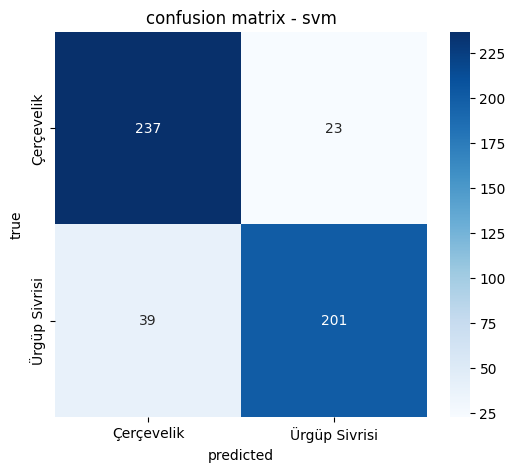

In [45]:
# plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('confusion matrix - svm')
plt.show()

# **Visualisasi Model SVM**

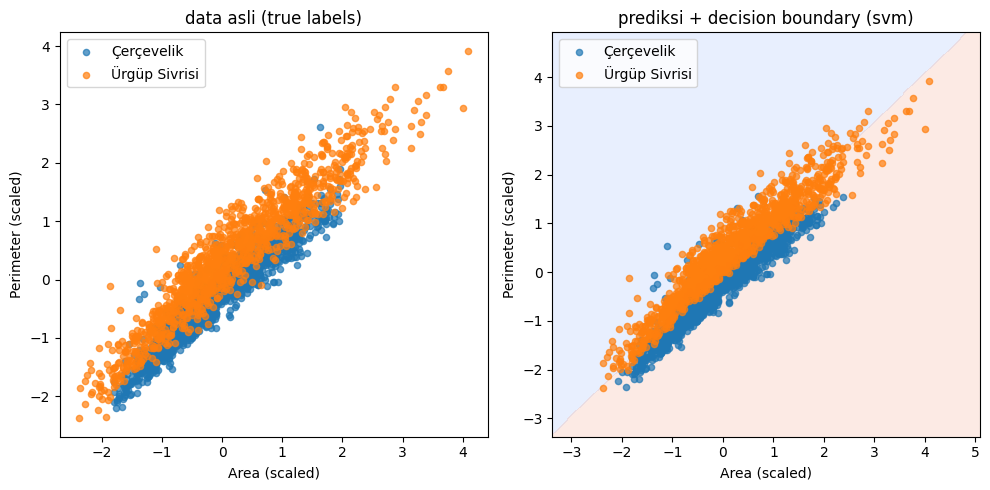

In [46]:
# cell 4 - visualisasi 2d + decision boundary
# pilih 2 fitur untuk plot (default: area & perimeter). ubah jika mau fitur lain.
f1 = 'Area'
f2 = 'Perimeter'

# siapkan data 2d (gunakan scaler yang sudah fit)
# ambil kolom f1,f2 dari seluruh X, lalu transform memakai scaler kolom lengkap:
# cara: ekstrak f1,f2 dari X, standardize manual berdasarkan scaler.mean_/scale_
cols_idx = [X.columns.get_loc(f1), X.columns.get_loc(f2)]
# transform seluruh X menggunakan scaler lalu ambil 2 kolom
X_scaled_all = scaler.transform(X)
X_plot = X_scaled_all[:, cols_idx]

# prediksi label pada seluruh titik (menggunakan model terlatih)
y_pred_all = svm.predict(X_scaled_all)

# scatter plot true label vs predicted overlay
plt.figure(figsize=(10,5))

# subplot kiri: data asli (true labels)
plt.subplot(1,2,1)
for i, cls in enumerate(le.classes_):
    mask = (le.transform(y_raw) == i)
    plt.scatter(X_plot[mask,0], X_plot[mask,1], s=20, label=str(cls), alpha=0.7)
plt.xlabel(f"{f1} (scaled)")
plt.ylabel(f"{f2} (scaled)")
plt.title("data asli (true labels)")
plt.legend()

# subplot kanan: decision boundary + predicted labels
plt.subplot(1,2,2)
# buat meshgrid untuk decision boundary (pada ruang fitur 2d)
x_min, x_max = X_plot[:,0].min() - 1, X_plot[:,0].max() + 1
y_min, y_max = X_plot[:,1].min() - 1, X_plot[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
# karena svm dilatih pada semua fitur (multi-dim), kita harus menyusun input untuk prediksi:
# strategy: buat array penuh dengan mean untuk fitur lain, dan set dua dimensi ke mesh coords
# buat array shape (n_points, n_features)
grid = np.zeros((xx.ravel().shape[0], X_scaled_all.shape[1]))
# isi grid dengan mean nilai (scaled) untuk fitur lainnya
grid[:] = np.mean(X_scaled_all, axis=0)
# set kolom f1/f2 ke mesh
grid[:, cols_idx[0]] = xx.ravel()
grid[:, cols_idx[1]] = yy.ravel()
# prediksi kelas pada grid
grid_pred = svm.predict(grid).reshape(xx.shape)

# plot boundary
plt.contourf(xx, yy, grid_pred, alpha=0.2, levels=np.arange(len(le.classes_)+1)-0.5, cmap='coolwarm')
# plot predicted points
for i, cls in enumerate(le.classes_):
    mask = (y_pred_all == i)
    plt.scatter(X_plot[mask,0], X_plot[mask,1], s=20, label=str(cls), alpha=0.7)
plt.xlabel(f"{f1} (scaled)")
plt.ylabel(f"{f2} (scaled)")
plt.title("prediksi + decision boundary (svm)")
plt.legend()

plt.tight_layout()
plt.show()

# **3D Visualisasi Hasil Model SVM**

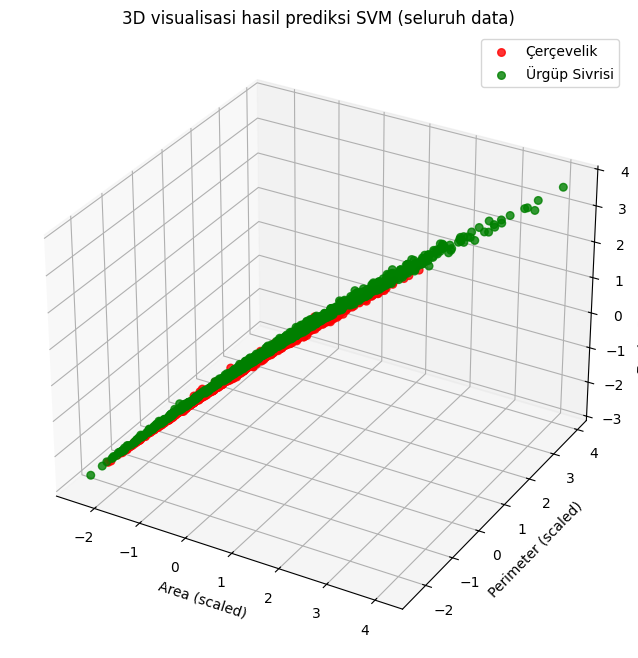

In [47]:
# cell 5 - 3d visualisasi hasil prediksi svm
# pilih 3 fitur (default: area, perimeter, equiv_diameter)
f3 = 'Equiv_Diameter'
ftrs_3d = [f1, f2, f3]
idxs_3d = [X.columns.get_loc(c) for c in ftrs_3d]

# ambil scaled coords untuk 3 fitur
X3d = X_scaled_all[:, idxs_3d]
y_pred_3d = y_pred_all  # hasil prediksi pada seluruh titik

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

colors = ['r','g','b','c','m','y']  # cukup warna untuk beberapa kelas
for i, cls in enumerate(le.classes_):
    mask = (y_pred_3d == i)
    ax.scatter(X3d[mask,0], X3d[mask,1], X3d[mask,2],
               c=colors[i % len(colors)], label=str(cls), s=30, alpha=0.8)

ax.set_xlabel(ftrs_3d[0] + " (scaled)")
ax.set_ylabel(ftrs_3d[1] + " (scaled)")
ax.set_zlabel(ftrs_3d[2] + " (scaled)")
ax.set_title("3D visualisasi hasil prediksi SVM (seluruh data)")
ax.legend()
plt.show()

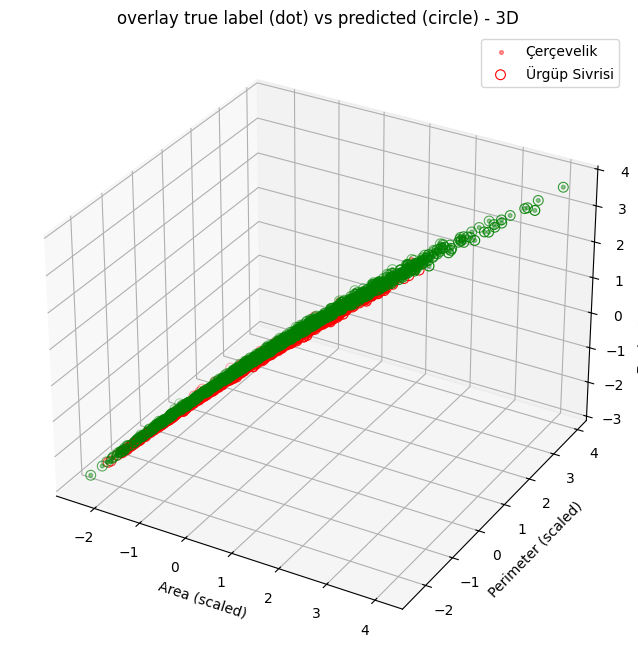

In [48]:
# 3d overlay: true label marker ('.') vs predicted label marker ('o' edge)
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for i, cls in enumerate(le.classes_):
    mask_true = (le.transform(y_raw) == i)
    mask_pred = (y_pred_all == i)
    # true points (semi-transparent)
    ax.scatter(X3d[mask_true,0], X3d[mask_true,1], X3d[mask_true,2],
               c=colors[i % len(colors)], marker='.', s=30, alpha=0.4)
    # predicted points as outlined markers
    ax.scatter(X3d[mask_pred,0], X3d[mask_pred,1], X3d[mask_pred,2],
               facecolors='none', edgecolors=colors[i % len(colors)], marker='o', s=50, linewidths=0.8)

ax.set_xlabel(ftrs_3d[0] + " (scaled)")
ax.set_ylabel(ftrs_3d[1] + " (scaled)")
ax.set_zlabel(ftrs_3d[2] + " (scaled)")
ax.set_title("overlay true label (dot) vs predicted (circle) - 3D")
ax.legend(le.classes_)
plt.show()

In [49]:
# simpan model, scaler, dan label encoder ke Google Drive
import joblib
import os

# mount google drive dulu (jalankan sekali per session colab)
from google.colab import drive
drive.mount('/content/gdrive')

# buat folder tujuan kalau belum ada
save_dir = "/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum06/models"
os.makedirs(save_dir, exist_ok=True)

# simpan artefak model ke folder tersebut
joblib.dump(svm, os.path.join(save_dir, 'svm_pumpkin_seeds_model.joblib'))
joblib.dump(scaler, os.path.join(save_dir, 'scaler_pumpkin_seeds.joblib'))
joblib.dump(le, os.path.join(save_dir, 'label_encoder_pumpkin_seeds.joblib'))

print("✅ Model, scaler, dan label encoder berhasil disimpan ke Drive di folder:")
print(save_dir)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
✅ Model, scaler, dan label encoder berhasil disimpan ke Drive di folder:
/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum06/models
